In [101]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [ ]:
# This model is exclusively for regression, not classifiction.
# To make it for classification, switch out leaky ReLu for sigmoid activation and BCE, in addition to performing activation at the output layer.

# Model Inputs BELOW
# Batch_size: divides the entire training set into groups of the given size
# epochs: number of rounds the entire training set is used
# learning rate: weights - learning rate * dE/dw. dE/dw is the partial derivative
#                of the error function with respect to the weights. 
#                This is the size of every individual step the NN takes during gradient descent.
# nodes_p_layer: Number of hidden layers and nodes can be changed!

class NN():
    def __init__(self, batch_size=20, epochs=100, learning_rate=0.01, nodes_p_layer=[1,24,48,24,1]):
        # intialize seed
        
        # initialize network info
        self.layers = len(nodes_p_layer) - 1
        self.batch_size = batch_size
        self.epochs = epochs
        self.npl = nodes_p_layer
        self.alpha = learning_rate

        # initialize matricies
        self.b = []
        self.w = []
        self.y_temp = []
        self.z_temp = []

        for i in range(len(self.npl) - 1):
            self.w.append(np.random.randn(self.npl[i],self.npl[i + 1]) * np.sqrt(2 / self.npl[i])) # Need to randomize intial weights to break symmetry
            self.b.append(np.zeros((1,self.npl[i + 1]))) # Not concerned about randomizing since they aren't involved in the activation function

        # for backprop
        self.dEdw = []
        self.dEdb = []


    def train(self, x_train, x_valid, x_test, y_train, y_valid, y_test):
        train_error = []
        valid_error = []
        test_scores = []

        x_train, x_valid, x_test, y_train, y_valid, y_test = self.fix_format(x_train, x_valid, x_test, y_train, y_valid, y_test) 

        # for every epoch, run NN on every batch in training set, then check 
        # how it does on the validation set. ONLY backprop for training set.
        for round in range(self.epochs):

            batches_per_epoch = len(x_train) / self.batch_size

            for index in range(int(batches_per_epoch)):
                start = index * self.batch_size
                end = start + self.batch_size
                
                 # define batch
                x = x_train[start:end]
                y = y_train[start:end]

                self.forward_prop(x) # predict x y
                self.back_prop(y) # calculate gradients according to error (difference between predicted and truth)
                self.update_weights_biases() # update weights 
                self.refresh() # re-initialize variables

            trls = self.error(y_train, self.forward_prop(x_train))
            vls = self.error(y_valid, self.forward_prop(x_valid))

            train_error.append(trls)
            valid_error.append(vls)
            test_scores.append(self.forward_prop(x_test))
        
        return train_error, valid_error, test_scores
    
    def fix_format(self, x_train, x_valid, x_test, y_train, y_valid, y_test):
        if x_train.ndim == 1: x_train = x_train.reshape(-1,1)
        if x_valid.ndim == 1: x_valid = x_valid.reshape(-1,1)
        if x_test.ndim == 1: x_test = x_test.reshape(-1,1)
        if y_train.ndim == 1: y_train = y_train.reshape(-1,1)
        if y_valid.ndim == 1: y_valid = y_valid.reshape(-1,1)
        if y_test.ndim == 1: y_test = y_test.reshape(-1,1)

        return x_train, x_valid, x_test, y_train, y_valid, y_test

    def forward_prop(self, x):
        self.y_temp = [x]
        self.z_temp = []

        self.dEdy = []; self.dEdz = []

        y = x
        for i in range(self.layers): 
            z = y @ self.w[i] + self.b[i]

            # If we are moving to a hidden layer, use ReLU activation to 
            # generate nonlinearity (allows NN to learn more complex functions)
            if i != self.layers - 1:
                y = self.relu(z)
            # If we are exiting the hidden layer, do not use an activation function
            # so that our predictions can be positive or negative.
            else:
                y = z
            
            self.z_temp.append(z)
            self.y_temp.append(y)

        return self.y_temp[-1]

    def back_prop(self, y_true):
        # calculate first layer
        dEdy = (self.y_temp[-1] - y_true) / y_true.shape[0]

        for index in reversed(range(self.layers)):
            dydx = self.y_temp[index]
           
            dEdw_curr = dydx.T @ dEdy
            self.dEdw.insert(0,dEdw_curr)

            dEdb_curr = np.sum(dEdy, axis=0, keepdims=True)
            self.dEdb.insert(0,dEdb_curr)

            # prepare dEdy again
            if index != 0:
                dEdz = dEdy @ self.w[index].T
                dEdy = dEdz * self.relu_prime(self.z_temp[index - 1])

    def update_weights_biases(self):
        for index in range(self.layers):
            self.w[index] -= self.alpha * self.dEdw[index]
            self.b[index] -= self.alpha * self.dEdb[index] 

    def refresh(self):
        self.y_temp = []
        self.z_temp = []
        self.dEdw = []
        self.dEdb = []

    def test(self, input):
        return self.forward_prop(input)

    def error(self, y_true, y_hat):
        return float(np.mean((np.array(y_true) - np.array(y_hat))**2))
    
    def relu(self, x): # leaky ReLU
        return np.where(x > 0.0, x, 0.01 * x)

    def relu_prime(self, x): # partial derivative of ReLU
        return np.where(x > 0.0, 1.0, 0.0)


In [120]:
# Function to add noise to the dataset

def add_noise(y, trial_num, noise_factor=0.1):
    # np.random.seed(trial_num)
    noise = np.random.normal(loc=0.0, scale=noise_factor, size=y.shape)
    return y + noise

The NN is trained on 10 different functions. The dots represent the training data infused with noise, the colorful line represents the NN approximation, and the black hashed line represent the true function.

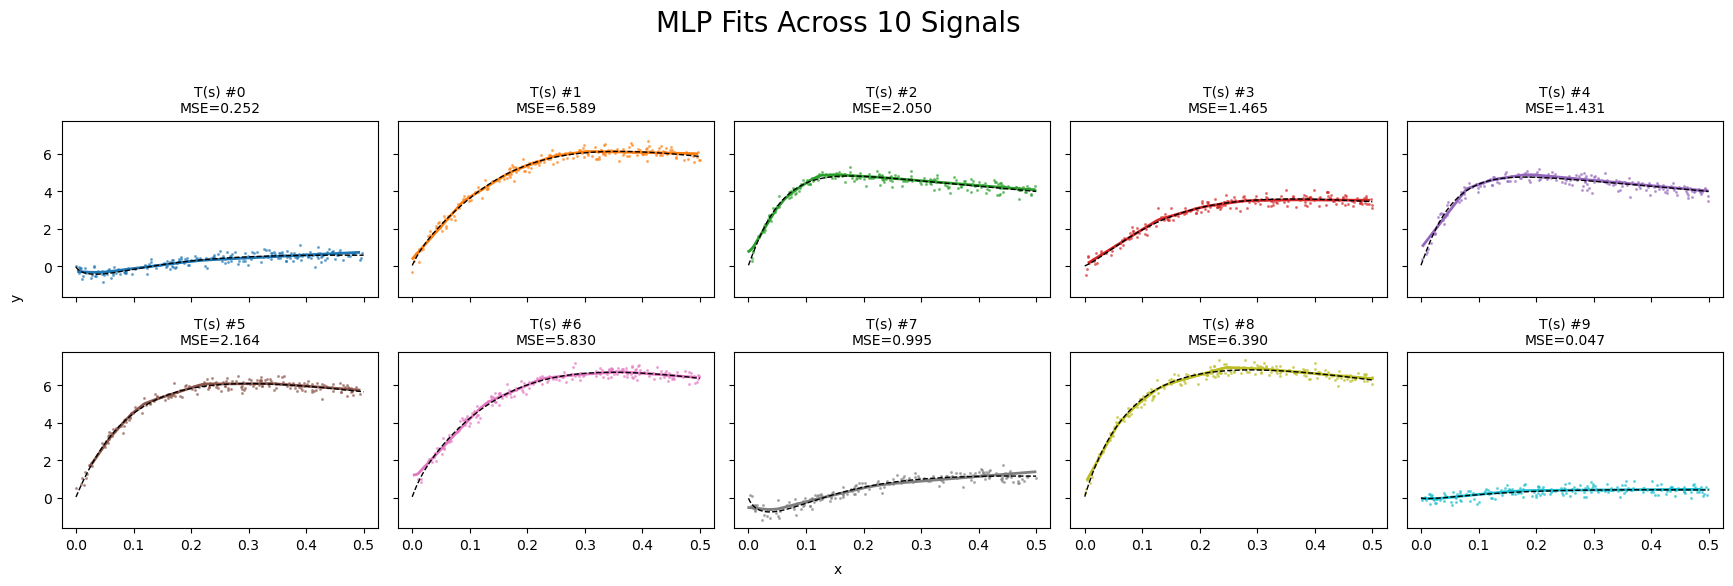

In [ ]:
# Load in data
ys = np.load('NN_test_data.npy')
x = np.linspace(0,0.5,1000)
loss_curves = []

# Prepare subplots for visualizing fit for each sample
fig, axes = plt.subplots(2, 5, figsize=(18, 6), sharex=True, sharey=True)
axes = axes.flatten()
colors = plt.cm.tab10(np.arange(10))

for i in range(10):
    ax = axes[i]
    color = colors[i]
    y = ys[i]

    # randomize order of data to prevent overfitting to a specific section of the functions
    order = np.arange(len(x))
    np.random.shuffle(order)

    x_train, y_train = x[order[0:200]], y[order[0:200]] # only train on a random subset of the data to make the task more difficult
    x_valid, y_valid = x[order[800:900]], y[order[800:900]]
    x_test, y_test = x[order[900:]], y[order[900:]]

    # add noise to training set to make data slightly more realistic
    y_train = add_noise(y_train, i, noise_factor=0.2)

    # instantiate NN object
    net = NN(batch_size=50, epochs=2000, learning_rate=0.005, nodes_p_layer=[1,40,80,40,1])
    
    # train model / collect error
    train_error, valid_error, test_scores = net.train(x_train, x_valid, x_test, y_train, y_valid, y_test)
    loss_curves.append((train_error, valid_error))
    
    # scatter plot of training data infused with noise
    ax.scatter(x_train, y_train, s=1.5, alpha=0.5, color=color)

    # plot of NN prediction
    reorder = np.argsort(x_test)
    ax.plot(x_test[reorder], test_scores[-1][reorder], color=color, linewidth=2)

    # plot of true function
    ax.plot(x, y, color='black', linestyle='dashed', linewidth=1)

    # subplot title
    mse = net.error(y_test, test_scores[-1])
    ax.set_title(f'T(s) #{i}\nMSE={mse:.3f}', fontsize=10)


fig.suptitle('MLP Fits Across 10 Signals', fontsize=20)
fig.text(0.5, 0.04, 'x', ha='center')
fig.text(0.04, 0.5, 'y', va='center', rotation='vertical')

plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.show()


In [132]:
# Rough plot of training and validation error if curious.

# for i in range(10):
#     plt.plot(loss_curves[i][0], label= f'train error {i}')
#     plt.plot(loss_curves[i][1], label= f'valid error {i}', linestyle='dashed')
#     plt.legend()
#     plt.show()
